In [1]:
# ============================================================
# MODULE 9 — EFFICIENT FRONTIER & PORTFOLIO OPTIMIZATION
# 1. Load and Validate Dataset
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

DATA_PATH = "../backend/data/feature_engineered_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df.sort_values(["Stock", "Date"])
      .reset_index(drop=True)
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(
    "Date range:",
    df["Date"].min().date(),
    "to",
    df["Date"].max().date()
)
print("Number of stocks:", df["Stock"].nunique())

Dataset loaded successfully.
Shape: (70764, 37)
Date range: 2020-01-02 to 2025-12-31
Number of stocks: 49


In [2]:
# ============================================================
# MODULE 9 — SECTION 2
# Construct Common 49-Stock Return Matrix
# ============================================================

# Create stock-by-date return matrix
returns_matrix = (
    df.pivot(
        index="Date",
        columns="Stock",
        values="Daily_Return"
    )
    .sort_index()
)

print("Initial return matrix shape:", returns_matrix.shape)

# Keep only dates where all 49 stocks have valid returns
common_returns = returns_matrix.dropna(axis=0, how="any")

print("Common-history return matrix shape:", common_returns.shape)

print(
    "Common history:",
    common_returns.index.min().date(),
    "to",
    common_returns.index.max().date()
)

print("Number of stocks:", common_returns.shape[1])

# Validation
if common_returns.shape[1] != 49:
    raise ValueError(
        f"Expected 49 stocks, found {common_returns.shape[1]}"
    )

if common_returns.isna().sum().sum() != 0:
    raise ValueError("Missing values remain in common return matrix.")

if not common_returns.index.is_monotonic_increasing:
    raise ValueError("Dates are not sorted chronologically.")

print("Missing values:", common_returns.isna().sum().sum())
print("Date order check: PASS")
print("Stock count check: PASS")

Initial return matrix shape: (1470, 49)
Common-history return matrix shape: (579, 49)
Common history: 2023-08-22 to 2025-12-31
Number of stocks: 49
Missing values: 0
Date order check: PASS
Stock count check: PASS


In [3]:
# ============================================================
# MODULE 9 — SECTION 3
# Expected Annual Returns
# ============================================================

TRADING_DAYS = 252

# Number of observations
n_observations = len(common_returns)

# Cumulative growth of ₹1 invested in each stock
cumulative_growth = (1 + common_returns).prod()

# Annualized expected return
annual_returns = (
    cumulative_growth ** (TRADING_DAYS / n_observations)
) - 1

annual_returns = annual_returns.sort_values(ascending=False)

print("Expected annual returns calculated.")
print()
print("Number of stocks:", len(annual_returns))
print("Observation period:", n_observations, "trading days")
print()

print("Top 10 annualized returns:")
print(
    (annual_returns.head(10) * 100)
    .round(2)
    .to_string()
)

print()
print("Bottom 10 annualized returns:")
print(
    (annual_returns.tail(10) * 100)
    .round(2)
    .to_string()
)

# Validation
if len(annual_returns) != 49:
    raise ValueError("Expected annual return for all 49 stocks.")

if not np.isfinite(annual_returns).all():
    raise ValueError("Non-finite annual return detected.")

print()
print("Annual return validity check: PASS")

Expected annual returns calculated.

Number of stocks: 49
Observation period: 579 trading days

Top 10 annualized returns:
Stock
BEL           64.71
ETERNAL       63.58
SHRIRAMFIN    56.96
BHARTIARTL    47.66
M&M           47.65
EICHERMOT     41.64
TRENT         39.30
HEROMOTOCO    38.37
BAJAJ-AUTO    37.96
COALINDIA     36.94

Bottom 10 annualized returns:
Stock
HDFCLIFE       8.53
NESTLEIND      8.14
JIOFIN         7.74
DRREDDY        3.77
ITC           -0.01
TCS           -0.15
HINDUNILVR    -2.34
ASIANPAINT    -4.89
ADANIENT      -6.87
INDUSINDBK   -18.49

Annual return validity check: PASS


In [4]:
# ============================================================
# MODULE 9 — SECTION 4
# Covariance Matrix
# ============================================================

# Daily covariance matrix
covariance_daily = common_returns.cov()

# Annualized covariance matrix
covariance_annual = covariance_daily * TRADING_DAYS

print("Daily covariance matrix shape:", covariance_daily.shape)
print("Annualized covariance matrix shape:", covariance_annual.shape)

# Basic statistics
diagonal_values = np.diag(covariance_annual)

print()
print("Annualized volatility range:")
print(
    "Minimum:",
    f"{np.sqrt(diagonal_values.min()) * 100:.2f}%"
)
print(
    "Maximum:",
    f"{np.sqrt(diagonal_values.max()) * 100:.2f}%"
)

print()
print("Covariance matrix validation:")

# Shape check
if covariance_annual.shape != (49, 49):
    raise ValueError("Covariance matrix must be 49 × 49.")

# Missing-value check
if covariance_annual.isna().sum().sum() != 0:
    raise ValueError("Covariance matrix contains missing values.")

# Symmetry check
if not np.allclose(
    covariance_annual.values,
    covariance_annual.values.T,
    atol=1e-12
):
    raise ValueError("Covariance matrix is not symmetric.")

# Finite-value check
if not np.isfinite(covariance_annual.values).all():
    raise ValueError("Covariance matrix contains non-finite values.")

print("Shape check: PASS")
print("Missing-value check: PASS")
print("Symmetry check: PASS")
print("Finite-value check: PASS")

Daily covariance matrix shape: (49, 49)
Annualized covariance matrix shape: (49, 49)

Annualized volatility range:
Minimum: 16.73%
Maximum: 39.55%

Covariance matrix validation:
Shape check: PASS
Missing-value check: PASS
Symmetry check: PASS
Finite-value check: PASS


In [5]:
# ============================================================
# MODULE 9 — SECTION 5
# Portfolio Calculation Functions
# ============================================================

RISK_FREE_RATE = 0.0

# Convert Series/DataFrame to NumPy arrays
expected_returns = annual_returns.values
cov_matrix = covariance_annual.values

NUM_STOCKS = len(expected_returns)


def portfolio_return(weights):
    """
    Calculate annualized portfolio return.
    """
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights):
    """
    Calculate annualized portfolio volatility.
    """
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )


def portfolio_sharpe(weights):
    """
    Calculate portfolio Sharpe ratio.
    """
    return (
        portfolio_return(weights) - RISK_FREE_RATE
    ) / portfolio_volatility(weights)


# ------------------------------------------------------------
# Test with equal-weight portfolio
# ------------------------------------------------------------

equal_weights = np.ones(NUM_STOCKS) / NUM_STOCKS

ew_return = portfolio_return(equal_weights)
ew_volatility = portfolio_volatility(equal_weights)
ew_sharpe = portfolio_sharpe(equal_weights)

print("Equal-weight portfolio:")
print()
print(f"Number of stocks : {NUM_STOCKS}")
print(f"Weight per stock : {equal_weights[0]:.6f}")
print(f"Weight sum       : {equal_weights.sum():.6f}")
print(f"Annual return    : {ew_return * 100:.2f}%")
print(f"Annual volatility: {ew_volatility * 100:.2f}%")
print(f"Sharpe ratio     : {ew_sharpe:.4f}")


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if not np.isclose(equal_weights.sum(), 1.0):
    raise ValueError("Portfolio weights do not sum to 1.")

if np.any(equal_weights < 0):
    raise ValueError("Negative weights detected.")

if not np.isfinite(ew_return):
    raise ValueError("Portfolio return is not finite.")

if not np.isfinite(ew_volatility):
    raise ValueError("Portfolio volatility is not finite.")

if ew_volatility <= 0:
    raise ValueError("Portfolio volatility must be positive.")

print()
print("Weight sum check: PASS")
print("Non-negative weight check: PASS")
print("Portfolio calculation check: PASS")

Equal-weight portfolio:

Number of stocks : 49
Weight per stock : 0.020408
Weight sum       : 1.000000
Annual return    : 20.59%
Annual volatility: 13.43%
Sharpe ratio     : 1.5340

Weight sum check: PASS
Non-negative weight check: PASS
Portfolio calculation check: PASS


In [6]:
# ============================================================
# MODULE 9 — SECTION 6
# Generate Random Portfolios
# ============================================================

NUM_RANDOM_PORTFOLIOS = 10000

rng = np.random.default_rng(42)

random_results = []

for _ in range(NUM_RANDOM_PORTFOLIOS):

    # Generate random positive weights
    weights = rng.dirichlet(np.ones(NUM_STOCKS))

    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    sharpe = (ret - RISK_FREE_RATE) / vol

    random_results.append(
        [ret, vol, sharpe]
    )

random_results = np.array(random_results)

random_returns = random_results[:, 0]
random_volatilities = random_results[:, 1]
random_sharpes = random_results[:, 2]

print("Random portfolios generated:", NUM_RANDOM_PORTFOLIOS)
print()
print(
    f"Return range     : "
    f"{random_returns.min() * 100:.2f}% "
    f"to "
    f"{random_returns.max() * 100:.2f}%"
)

print(
    f"Volatility range : "
    f"{random_volatilities.min() * 100:.2f}% "
    f"to "
    f"{random_volatilities.max() * 100:.2f}%"
)

print(
    f"Sharpe range     : "
    f"{random_sharpes.min():.4f} "
    f"to "
    f"{random_sharpes.max():.4f}"
)

# Validation
if random_results.shape != (NUM_RANDOM_PORTFOLIOS, 3):
    raise ValueError("Unexpected random portfolio result shape.")

if not np.isfinite(random_results).all():
    raise ValueError("Non-finite random portfolio result detected.")

print()
print("Portfolio generation shape check: PASS")
print("Finite-value check: PASS")

Random portfolios generated: 10000

Return range     : 12.44% to 30.38%
Volatility range : 11.77% to 16.86%
Sharpe range     : 0.8420 to 2.4673

Portfolio generation shape check: PASS
Finite-value check: PASS


In [7]:
# ============================================================
# MODULE 9 — SECTION 7
# Minimum Volatility Portfolio
# ============================================================

# Initial guess: equal-weight portfolio
initial_weights = np.ones(NUM_STOCKS) / NUM_STOCKS

# Portfolio must be fully invested
constraints = (
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    },
)

# Long-only portfolio
bounds = tuple(
    (0.0, 1.0)
    for _ in range(NUM_STOCKS)
)

# Minimize portfolio volatility
min_vol_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 1000,
        "ftol": 1e-12,
        "disp": False
    }
)

if not min_vol_result.success:
    raise RuntimeError(
        f"Minimum-volatility optimization failed: "
        f"{min_vol_result.message}"
    )

min_vol_weights = min_vol_result.x

min_vol_return = portfolio_return(min_vol_weights)
min_vol_volatility = portfolio_volatility(min_vol_weights)
min_vol_sharpe = portfolio_sharpe(min_vol_weights)

print("Minimum-volatility optimization: SUCCESS")
print()
print(f"Expected return : {min_vol_return * 100:.2f}%")
print(f"Volatility      : {min_vol_volatility * 100:.2f}%")
print(f"Sharpe ratio    : {min_vol_sharpe:.4f}")
print(f"Weight sum      : {min_vol_weights.sum():.6f}")
print(f"Minimum weight  : {min_vol_weights.min():.6f}")
print(f"Maximum weight  : {min_vol_weights.max():.6f}")

# Validation
if not np.isclose(min_vol_weights.sum(), 1.0, atol=1e-8):
    raise ValueError("Minimum-volatility weights do not sum to 1.")

if np.any(min_vol_weights < -1e-8):
    raise ValueError("Negative weights detected.")

if not np.isfinite(min_vol_weights).all():
    raise ValueError("Non-finite optimized weights detected.")

print()
print("Weight sum check: PASS")
print("Long-only constraint: PASS")
print("Finite weights check: PASS")

Minimum-volatility optimization: SUCCESS

Expected return : 18.90%
Volatility      : 9.98%
Sharpe ratio    : 1.8941
Weight sum      : 1.000000
Minimum weight  : 0.000000
Maximum weight  : 0.134393

Weight sum check: PASS
Long-only constraint: PASS
Finite weights check: PASS


In [8]:
# ============================================================
# MODULE 9 — SECTION 8
# Inspect Minimum-Volatility Portfolio Weights
# ============================================================

min_vol_weights_df = pd.DataFrame({
    "Stock": common_returns.columns,
    "Weight": min_vol_weights
})

min_vol_weights_df["Weight_Percent"] = (
    min_vol_weights_df["Weight"] * 100
)

min_vol_weights_df = (
    min_vol_weights_df
    .sort_values("Weight", ascending=False)
    .reset_index(drop=True)
)

# Count active positions
active_positions = (
    min_vol_weights_df["Weight"] > 1e-6
).sum()

zero_positions = (
    min_vol_weights_df["Weight"] <= 1e-6
).sum()

print("Minimum-volatility portfolio weight analysis")
print()

print("Top 10 portfolio weights:")
print(
    min_vol_weights_df.head(10)[
        ["Stock", "Weight_Percent"]
    ].to_string(
        index=False,
        formatters={
            "Weight_Percent": "{:.2f}%".format
        }
    )
)

print()
print("Active positions:", active_positions)
print("Zero-weight positions:", zero_positions)
print(
    "Total allocation:",
    f"{min_vol_weights_df['Weight'].sum() * 100:.2f}%"
)

# Validation
if not np.isclose(
    min_vol_weights_df["Weight"].sum(),
    1.0,
    atol=1e-8
):
    raise ValueError("Weight allocation does not equal 100%.")

print()
print("Allocation reconciliation: PASS")

Minimum-volatility portfolio weight analysis

Top 10 portfolio weights:
     Stock Weight_Percent
HINDUNILVR         13.44%
       ITC         11.22%
       TCS          9.85%
 SUNPHARMA          9.43%
 ICICIBANK          9.02%
  HDFCBANK          8.45%
   DRREDDY          7.27%
  HDFCLIFE          4.36%
    MARUTI          4.20%
     CIPLA          3.52%

Active positions: 19
Zero-weight positions: 30
Total allocation: 100.00%

Allocation reconciliation: PASS


In [9]:
# ============================================================
# MODULE 9 — SECTION 9
# Maximum Sharpe Portfolio
# ============================================================

def negative_sharpe(weights):
    """
    Negative Sharpe ratio for minimization.
    """
    return -portfolio_sharpe(weights)


# Start from equal weights
initial_weights_sharpe = np.ones(NUM_STOCKS) / NUM_STOCKS

max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights_sharpe,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 2000,
        "ftol": 1e-12,
        "disp": False
    }
)

if not max_sharpe_result.success:
    raise RuntimeError(
        f"Maximum-Sharpe optimization failed: "
        f"{max_sharpe_result.message}"
    )

max_sharpe_weights = max_sharpe_result.x

max_sharpe_return = portfolio_return(max_sharpe_weights)
max_sharpe_volatility = portfolio_volatility(max_sharpe_weights)
max_sharpe_value = portfolio_sharpe(max_sharpe_weights)

print("Maximum-Sharpe optimization: SUCCESS")
print()
print(f"Expected return : {max_sharpe_return * 100:.2f}%")
print(f"Volatility      : {max_sharpe_volatility * 100:.2f}%")
print(f"Sharpe ratio    : {max_sharpe_value:.4f}")
print(f"Weight sum      : {max_sharpe_weights.sum():.6f}")
print(f"Minimum weight  : {max_sharpe_weights.min():.6f}")
print(f"Maximum weight  : {max_sharpe_weights.max():.6f}")

# Validation
if not np.isclose(
    max_sharpe_weights.sum(),
    1.0,
    atol=1e-8
):
    raise ValueError(
        "Maximum-Sharpe weights do not sum to 1."
    )

if np.any(max_sharpe_weights < -1e-8):
    raise ValueError(
        "Negative weights detected."
    )

if not np.isfinite(max_sharpe_weights).all():
    raise ValueError(
        "Non-finite optimized weights detected."
    )

print()
print("Weight sum check: PASS")
print("Long-only constraint: PASS")
print("Finite weights check: PASS")

Maximum-Sharpe optimization: SUCCESS

Expected return : 47.66%
Volatility      : 13.17%
Sharpe ratio    : 3.6186
Weight sum      : 1.000000
Minimum weight  : 0.000000
Maximum weight  : 0.274611

Weight sum check: PASS
Long-only constraint: PASS
Finite weights check: PASS


In [10]:
# ============================================================
# MODULE 9 — SECTION 10
# Inspect Maximum-Sharpe Portfolio Weights
# ============================================================

max_sharpe_weights_df = pd.DataFrame({
    "Stock": common_returns.columns,
    "Weight": max_sharpe_weights
})

max_sharpe_weights_df["Weight_Percent"] = (
    max_sharpe_weights_df["Weight"] * 100
)

max_sharpe_weights_df = (
    max_sharpe_weights_df
    .sort_values("Weight", ascending=False)
    .reset_index(drop=True)
)

# Count active positions
active_positions_sharpe = (
    max_sharpe_weights_df["Weight"] > 1e-6
).sum()

zero_positions_sharpe = (
    max_sharpe_weights_df["Weight"] <= 1e-6
).sum()

print("Maximum-Sharpe portfolio weight analysis")
print()

print("Top 10 portfolio weights:")
print(
    max_sharpe_weights_df.head(10)[
        ["Stock", "Weight_Percent"]
    ].to_string(
        index=False,
        formatters={
            "Weight_Percent": "{:.2f}%".format
        }
    )
)

print()
print("Active positions:", active_positions_sharpe)
print("Zero-weight positions:", zero_positions_sharpe)

print(
    "Total allocation:",
    f"{max_sharpe_weights_df['Weight'].sum() * 100:.2f}%"
)

# Validation
if not np.isclose(
    max_sharpe_weights_df["Weight"].sum(),
    1.0,
    atol=1e-8
):
    raise ValueError(
        "Maximum-Sharpe allocation does not equal 100%."
    )

print()
print("Allocation reconciliation: PASS")

Maximum-Sharpe portfolio weight analysis

Top 10 portfolio weights:
     Stock Weight_Percent
APOLLOHOSP         27.46%
ASIANPAINT         26.18%
  AXISBANK         17.33%
BHARTIARTL          8.20%
     CIPLA          5.31%
BAJAJ-AUTO          4.65%
ADANIPORTS          4.55%
HINDUNILVR          3.18%
   DRREDDY          3.12%
SHRIRAMFIN          0.00%

Active positions: 9
Zero-weight positions: 40
Total allocation: 100.00%

Allocation reconciliation: PASS


In [11]:
# ============================================================
# MODULE 9 — SECTION 11
# Efficient Frontier
# ============================================================

# Target return range
frontier_min_return = min_vol_return
frontier_max_return = max_sharpe_return

target_returns = np.linspace(
    frontier_min_return,
    frontier_max_return,
    50
)

frontier_results = []

# Initial starting point
frontier_initial_weights = equal_weights.copy()

for target_return in target_returns:

    frontier_constraints = (
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights,
            target=target_return:
                portfolio_return(weights) - target
        }
    )

    result = minimize(
        portfolio_volatility,
        frontier_initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=frontier_constraints,
        options={
            "maxiter": 1000,
            "ftol": 1e-10,
            "disp": False
        }
    )

    if result.success:

        weights = result.x

        ret = portfolio_return(weights)
        vol = portfolio_volatility(weights)
        sharpe = portfolio_sharpe(weights)

        frontier_results.append(
            [ret, vol, sharpe]
        )

    else:
        print(
            f"Warning: optimization failed "
            f"for target return {target_return:.4f}"
        )


frontier_results = np.array(frontier_results)

frontier_returns = frontier_results[:, 0]
frontier_volatilities = frontier_results[:, 1]
frontier_sharpes = frontier_results[:, 2]

print("Efficient Frontier generated.")
print()
print("Target portfolios requested:", len(target_returns))
print("Successful portfolios:", len(frontier_results))

print()
print(
    f"Frontier return range: "
    f"{frontier_returns.min() * 100:.2f}% "
    f"to "
    f"{frontier_returns.max() * 100:.2f}%"
)

print(
    f"Frontier volatility range: "
    f"{frontier_volatilities.min() * 100:.2f}% "
    f"to "
    f"{frontier_volatilities.max() * 100:.2f}%"
)

# Validation
if len(frontier_results) < 2:
    raise RuntimeError(
        "Too few successful frontier optimizations."
    )

if not np.isfinite(frontier_results).all():
    raise ValueError(
        "Non-finite Efficient Frontier results detected."
    )

print()
print("Frontier optimization check: PASS")
print("Finite-value check: PASS")

Efficient Frontier generated.

Target portfolios requested: 50
Successful portfolios: 50

Frontier return range: 18.90% to 47.66%
Frontier volatility range: 9.98% to 13.17%

Frontier optimization check: PASS
Finite-value check: PASS


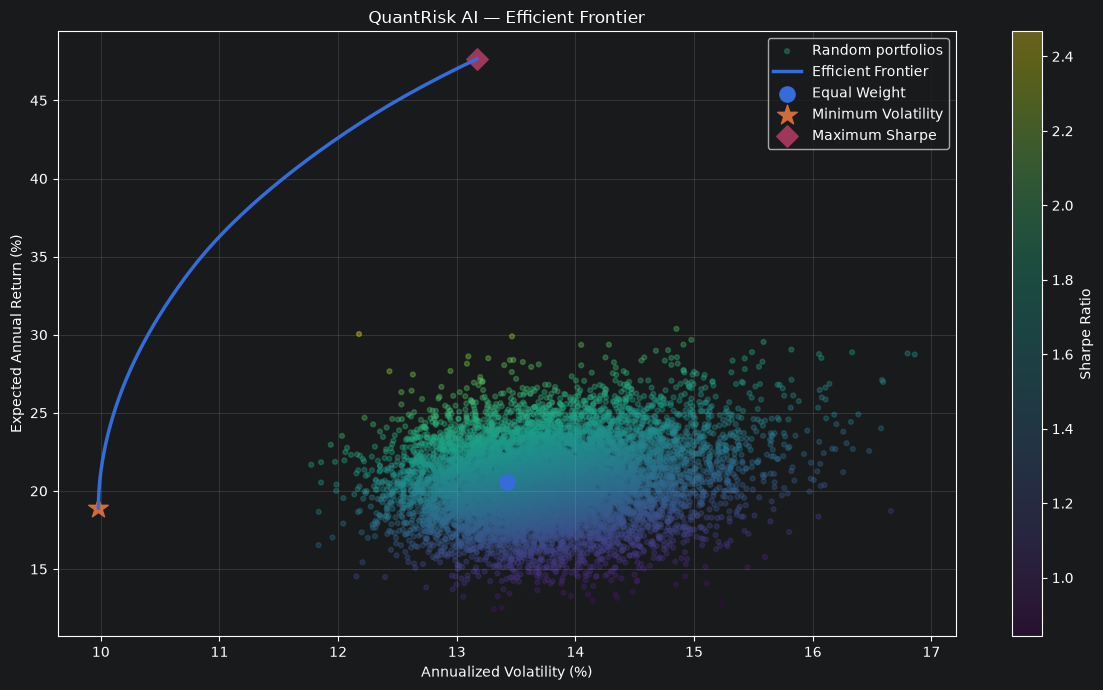

In [12]:
# ============================================================
# MODULE 9 — SECTION 12
# Efficient Frontier Visualization
# ============================================================

plt.figure(figsize=(12, 7))

# Random portfolios
scatter = plt.scatter(
    random_volatilities * 100,
    random_returns * 100,
    c=random_sharpes,
    cmap="viridis",
    alpha=0.35,
    s=12,
    label="Random portfolios"
)

# Efficient Frontier
plt.plot(
    frontier_volatilities * 100,
    frontier_returns * 100,
    linewidth=2.5,
    label="Efficient Frontier"
)

# Equal-weight portfolio
plt.scatter(
    ew_volatility * 100,
    ew_return * 100,
    marker="o",
    s=120,
    label="Equal Weight"
)

# Minimum-volatility portfolio
plt.scatter(
    min_vol_volatility * 100,
    min_vol_return * 100,
    marker="*",
    s=220,
    label="Minimum Volatility"
)

# Maximum-Sharpe portfolio
plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="D",
    s=120,
    label="Maximum Sharpe"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("QuantRisk AI — Efficient Frontier")

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# MODULE 9 — SECTION 13
# Portfolio Comparison
# ============================================================

def count_active_positions(weights, tolerance=1e-6):
    return int(np.sum(weights > tolerance))


portfolio_comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Volatility",
        "Maximum Sharpe"
    ],
    "Expected_Return": [
        ew_return,
        min_vol_return,
        max_sharpe_return
    ],
    "Volatility": [
        ew_volatility,
        min_vol_volatility,
        max_sharpe_volatility
    ],
    "Sharpe_Ratio": [
        ew_sharpe,
        min_vol_sharpe,
        max_sharpe_value
    ],
    "Active_Positions": [
        count_active_positions(equal_weights),
        count_active_positions(min_vol_weights),
        count_active_positions(max_sharpe_weights)
    ]
})

display(
    portfolio_comparison.style.format({
        "Expected_Return": "{:.2%}",
        "Volatility": "{:.2%}",
        "Sharpe_Ratio": "{:.4f}",
        "Active_Positions": "{:.0f}"
    })
)

# Validation
if len(portfolio_comparison) != 3:
    raise ValueError(
        "Portfolio comparison must contain exactly 3 portfolios."
    )

if portfolio_comparison[
    ["Expected_Return", "Volatility", "Sharpe_Ratio"]
].isna().any().any():
    raise ValueError(
        "Portfolio comparison contains missing values."
    )

print()
print("Portfolio comparison table: PASS")

,Portfolio,Expected_Return,Volatility,Sharpe_Ratio,Active_Positions
0,Equal Weight,20.59%,13.43%,1.5340,49
1,Minimum Volatility,18.90%,9.98%,1.8941,19
2,Maximum Sharpe,47.66%,13.17%,3.6186,9



Portfolio comparison table: PASS


In [14]:
# ============================================================
# MODULE 9 — SECTION 14
# Optimization Constraint Validation
# ============================================================

portfolios_to_validate = {
    "Equal Weight": equal_weights,
    "Minimum Volatility": min_vol_weights,
    "Maximum Sharpe": max_sharpe_weights
}

print("Portfolio constraint validation")
print()

for name, weights in portfolios_to_validate.items():

    weight_sum = weights.sum()
    min_weight = weights.min()
    max_weight = weights.max()

    print(name)
    print(f"  Weight sum : {weight_sum:.10f}")
    print(f"  Min weight : {min_weight:.10f}")
    print(f"  Max weight : {max_weight:.10f}")

    if not np.isclose(weight_sum, 1.0, atol=1e-8):
        raise ValueError(
            f"{name}: weights do not sum to 1."
        )

    if min_weight < -1e-8:
        raise ValueError(
            f"{name}: negative weight detected."
        )

print()
print("All portfolio constraints: PASS")


# ------------------------------------------------------------
# Metric consistency validation
# ------------------------------------------------------------

calculated_metrics = {
    "Equal Weight": (
        ew_return,
        ew_volatility,
        ew_sharpe
    ),
    "Minimum Volatility": (
        min_vol_return,
        min_vol_volatility,
        min_vol_sharpe
    ),
    "Maximum Sharpe": (
        max_sharpe_return,
        max_sharpe_volatility,
        max_sharpe_value
    )
}

for i, name in enumerate(
    portfolio_comparison["Portfolio"]
):

    stored_return = portfolio_comparison.loc[
        i, "Expected_Return"
    ]

    stored_volatility = portfolio_comparison.loc[
        i, "Volatility"
    ]

    stored_sharpe = portfolio_comparison.loc[
        i, "Sharpe_Ratio"
    ]

    calc_return, calc_volatility, calc_sharpe = (
        calculated_metrics[name]
    )

    if not np.isclose(
        stored_return,
        calc_return,
        atol=1e-10
    ):
        raise ValueError(
            f"{name}: return mismatch."
        )

    if not np.isclose(
        stored_volatility,
        calc_volatility,
        atol=1e-10
    ):
        raise ValueError(
            f"{name}: volatility mismatch."
        )

    if not np.isclose(
        stored_sharpe,
        calc_sharpe,
        atol=1e-10
    ):
        raise ValueError(
            f"{name}: Sharpe mismatch."
        )

print("Metric consistency check: PASS")

Portfolio constraint validation

Equal Weight
  Weight sum : 1.0000000000
  Min weight : 0.0204081633
  Max weight : 0.0204081633
Minimum Volatility
  Weight sum : 1.0000000000
  Min weight : 0.0000000000
  Max weight : 0.1343934842
Maximum Sharpe
  Weight sum : 1.0000000000
  Min weight : 0.0000000000
  Max weight : 0.2746108824

All portfolio constraints: PASS
Metric consistency check: PASS


In [15]:
# ============================================================
# MODULE 9 — SECTION 15
# Portfolio Weight Tables
# ============================================================

portfolio_weights = pd.DataFrame({
    "Stock": common_returns.columns,
    "Equal_Weight": equal_weights,
    "Minimum_Volatility": min_vol_weights,
    "Maximum_Sharpe": max_sharpe_weights
})

# Percentage representation
portfolio_weights["Equal_Weight_Pct"] = (
    portfolio_weights["Equal_Weight"] * 100
)

portfolio_weights["Minimum_Volatility_Pct"] = (
    portfolio_weights["Minimum_Volatility"] * 100
)

portfolio_weights["Maximum_Sharpe_Pct"] = (
    portfolio_weights["Maximum_Sharpe"] * 100
)

# Sort by Maximum-Sharpe allocation
portfolio_weights = (
    portfolio_weights
    .sort_values(
        "Maximum_Sharpe",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Portfolio weight table created.")
print()
print("Top 10 stocks by Maximum-Sharpe allocation:")

print(
    portfolio_weights.head(10)[
        [
            "Stock",
            "Equal_Weight_Pct",
            "Minimum_Volatility_Pct",
            "Maximum_Sharpe_Pct"
        ]
    ].to_string(
        index=False,
        formatters={
            "Equal_Weight_Pct": "{:.2f}%".format,
            "Minimum_Volatility_Pct": "{:.2f}%".format,
            "Maximum_Sharpe_Pct": "{:.2f}%".format
        }
    )
)

# Validation
for column in [
    "Equal_Weight",
    "Minimum_Volatility",
    "Maximum_Sharpe"
]:

    if not np.isclose(
        portfolio_weights[column].sum(),
        1.0,
        atol=1e-8
    ):
        raise ValueError(
            f"{column} weights do not sum to 1."
        )

print()
print("Equal-weight allocation: PASS")
print("Minimum-volatility allocation: PASS")
print("Maximum-Sharpe allocation: PASS")
print("Weight table validation: PASS")

Portfolio weight table created.

Top 10 stocks by Maximum-Sharpe allocation:
     Stock Equal_Weight_Pct Minimum_Volatility_Pct Maximum_Sharpe_Pct
APOLLOHOSP            2.04%                  3.08%             27.46%
ASIANPAINT            2.04%                  3.14%             26.18%
  AXISBANK            2.04%                  0.00%             17.33%
BHARTIARTL            2.04%                  1.18%              8.20%
     CIPLA            2.04%                  3.52%              5.31%
BAJAJ-AUTO            2.04%                  0.68%              4.65%
ADANIPORTS            2.04%                  0.00%              4.55%
HINDUNILVR            2.04%                 13.44%              3.18%
   DRREDDY            2.04%                  7.27%              3.12%
SHRIRAMFIN            2.04%                  0.00%              0.00%

Equal-weight allocation: PASS
Minimum-volatility allocation: PASS
Maximum-Sharpe allocation: PASS
Weight table validation: PASS


In [16]:
# ============================================================
# MODULE 9 — SECTION 16
# Export Portfolio Optimization Results
# ============================================================

OUTPUT_DIR = "models/efficient_frontier"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# 1. Portfolio comparison
# ------------------------------------------------------------

comparison_path = os.path.join(
    OUTPUT_DIR,
    "portfolio_comparison.csv"
)

portfolio_comparison.to_csv(
    comparison_path,
    index=False
)


# ------------------------------------------------------------
# 2. Portfolio weights
# ------------------------------------------------------------

weights_path = os.path.join(
    OUTPUT_DIR,
    "portfolio_weights.csv"
)

portfolio_weights.to_csv(
    weights_path,
    index=False
)


# ------------------------------------------------------------
# 3. Efficient Frontier
# ------------------------------------------------------------

frontier_df = pd.DataFrame({
    "Expected_Return": frontier_returns,
    "Volatility": frontier_volatilities,
    "Sharpe_Ratio": frontier_sharpes
})

frontier_path = os.path.join(
    OUTPUT_DIR,
    "efficient_frontier.csv"
)

frontier_df.to_csv(
    frontier_path,
    index=False
)


# ------------------------------------------------------------
# 4. Random portfolios
# ------------------------------------------------------------

random_portfolios_df = pd.DataFrame({
    "Expected_Return": random_returns,
    "Volatility": random_volatilities,
    "Sharpe_Ratio": random_sharpes
})

random_path = os.path.join(
    OUTPUT_DIR,
    "random_portfolios.csv"
)

random_portfolios_df.to_csv(
    random_path,
    index=False
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

export_paths = [
    comparison_path,
    weights_path,
    frontier_path,
    random_path
]

for path in export_paths:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Export failed: {path}"
        )

print("Module 9 exports completed.")
print()

for path in export_paths:
    print("Saved:", path)

print()
print("Export validation: PASS")

Module 9 exports completed.

Saved: models/efficient_frontier\portfolio_comparison.csv
Saved: models/efficient_frontier\portfolio_weights.csv
Saved: models/efficient_frontier\efficient_frontier.csv
Saved: models/efficient_frontier\random_portfolios.csv

Export validation: PASS


# MODULE 9 — METHODOLOGY & ASSUMPTION CHECKLIST

## Dataset

- Source: Module 3 feature-engineered dataset
- Portfolio universe: 49 stocks
- Common-history period: 2023-08-22 to 2025-12-31
- Common observations: 579 trading days
- Missing returns after common-history filtering: 0

## Expected Returns

- Daily stock returns were used.
- Historical cumulative returns were compounded.
- Returns were annualized using 252 trading days.
- Expected returns represent historical estimates, not forecasts.

## Covariance

- Daily return covariance matrix was calculated.
- Covariance was annualized using a factor of 252.
- Covariance matrix dimensions: 49 × 49.
- Matrix symmetry and finite-value checks passed.

## Portfolio Constraints

- Long-only portfolio.
- No short selling.
- Portfolio weights sum to 100%.
- No maximum individual-stock weight was imposed in the unconstrained optimization.
- Risk-free rate assumption: 0%.

## Portfolio Strategies

### Equal Weight

Each of the 49 stocks receives:

1 / 49 = 2.0408%

### Minimum Volatility

Objective:

Minimize portfolio volatility.

### Maximum Sharpe

Objective:

Maximize the Sharpe ratio using a 0% risk-free rate.

### Efficient Frontier

For a sequence of target returns, minimize portfolio volatility subject to:

- Target portfolio return
- Weight sum = 1
- Non-negative weights

## Validation

- Portfolio weight constraints: PASS
- Portfolio metric consistency: PASS
- Efficient Frontier optimizations: 50 / 50 successful
- Export validation: PASS

## Interpretation

The optimization results are historical, model-based estimates.

They should not be interpreted as guaranteed future returns or investment recommendations.

The unconstrained Maximum-Sharpe portfolio can become concentrated because no individual-stock weight cap was imposed.

A practical production portfolio could require additional constraints such as position limits, sector limits, turnover constraints, or other portfolio-mandate requirements.

In [17]:
# ============================================================
# MODULE 9 — SECTION 18
# FINAL MODULE SUMMARY
# ============================================================

print("=" * 65)
print("MODULE 9 — EFFICIENT FRONTIER & PORTFOLIO OPTIMIZATION")
print("=" * 65)

print()
print("Portfolio Universe       :", NUM_STOCKS, "stocks")
print("Common Trading Days      :", n_observations)
print(
    "Common Period            :",
    common_returns.index.min().date(),
    "to",
    common_returns.index.max().date()
)

print()
print("PORTFOLIO RESULTS")
print("-" * 65)

for _, row in portfolio_comparison.iterrows():

    print(f"\n{row['Portfolio']}")
    print(
        f"  Expected Return : "
        f"{row['Expected_Return']:.2%}"
    )
    print(
        f"  Volatility      : "
        f"{row['Volatility']:.2%}"
    )
    print(
        f"  Sharpe Ratio    : "
        f"{row['Sharpe_Ratio']:.4f}"
    )
    print(
        f"  Active Positions: "
        f"{int(row['Active_Positions'])}"
    )

print()
print("EFFICIENT FRONTIER")
print("-" * 65)
print("Target portfolios :", len(target_returns))
print("Successful        :", len(frontier_results))

print()
print("VALIDATION")
print("-" * 65)
print("Portfolio constraints       : PASS")
print("Metric consistency         : PASS")
print("Efficient Frontier         : PASS")
print("Export validation           : PASS")

print()
print("EXPORTED FILES")
print("-" * 65)

for path in export_paths:
    print(path)

print()
print("=" * 65)
print("MODULE 9 — COMPLETED")
print("=" * 65)

MODULE 9 — EFFICIENT FRONTIER & PORTFOLIO OPTIMIZATION

Portfolio Universe       : 49 stocks
Common Trading Days      : 579
Common Period            : 2023-08-22 to 2025-12-31

PORTFOLIO RESULTS
-----------------------------------------------------------------

Equal Weight
  Expected Return : 20.59%
  Volatility      : 13.43%
  Sharpe Ratio    : 1.5340
  Active Positions: 49

Minimum Volatility
  Expected Return : 18.90%
  Volatility      : 9.98%
  Sharpe Ratio    : 1.8941
  Active Positions: 19

Maximum Sharpe
  Expected Return : 47.66%
  Volatility      : 13.17%
  Sharpe Ratio    : 3.6186
  Active Positions: 9

EFFICIENT FRONTIER
-----------------------------------------------------------------
Target portfolios : 50
Successful        : 50

VALIDATION
-----------------------------------------------------------------
Portfolio constraints       : PASS
Metric consistency         : PASS
Efficient Frontier         : PASS
Export validation           : PASS

EXPORTED FILES
---------------